#  Smart Campus Energy Management System

###  Team Members:
* **Hossam Ahmed** : 2405306
* **Youssef Hamdy** : 2405308
* **Hana Adel** : 2405345
* **Asmaa Elshahat** : 2305130
* **Mostafa Amgad** : 2405015

---

##  Dataset Description
The dataset represents real-time monitoring of campus facilities to optimize energy consumption. It includes ** records** of various spaces like Labs, Offices, and Classrooms.

###  Key Features:
1. **Space ID**: Unique identifier for each campus area.
2. **Utilization Ratio**: Percentage of space occupancy (0 to 1).
3. **Energy Consumption (power_kwh)**: Current electricity usage in Kilowatts.
4. **N People (connected_devices)**: Number of active users or devices.
5. **Indoor Temperature**: Current temperature recorded in the area.

---

##  Project Objectives
Our system follows a multi-stage intelligent pipeline:
* **Clustering (K-Medoids)**: Grouping campus spaces based on usage patterns using *Manhattan Distance*.
* **Risk Assessment (Fuzzy Logic)**: Determining the 'Energy Waste Risk' based on occupancy vs. power usage.
* **Optimization (Genetic Algorithm)**: Finding the best temperature and HVAC settings to minimize waste.
* **Automated Decision Making**: Providing final commands (Shutdown/Optimize/Normal) for each space.

In [26]:
#Exploratory Data Analysis (EDA)


In [27]:
import pandas as pd

df = pd.read_csv(r"C:\Users\hossa\OneDrive\Desktop\New folder\smart_campus_dataset.csv")
df.head()

,hour_index,day_index,week_index,space_id,capacity,occupancy_count,utilization_ratio,idle_minutes,power_kwh,hvac_state,...,voltage_variation,device_temperature,zone_id,connected_devices,bandwidth_usage,packet_loss_rate,corridor_id,entry_count,exit_count,density_index
0,6,3,16,165,97,84,0.87,13,42.37,1,...,9.39,63.1,17,390,211.72,4.90,25,252,284,4.02
1,19,4,5,137,113,94,0.83,12,33.97,0,...,2.14,54.2,14,283,333.72,0.88,4,122,32,4.82
2,14,7,4,21,137,133,0.97,40,49.41,0,...,6.81,56.6,13,135,823.41,4.45,24,330,35,2.48
3,10,6,27,5,83,34,0.41,3,48.29,0,...,0.57,53.5,11,35,300.11,8.93,7,24,453,1.53
4,7,7,4,178,83,54,0.65,50,24.89,0,...,0.55,25.1,6,436,0.54,8.71,4,55,133,2.94


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   hour_index                 100000 non-null  int64  
 1   day_index                  100000 non-null  int64  
 2   week_index                 100000 non-null  int64  
 3   space_id                   100000 non-null  int64  
 4   capacity                   100000 non-null  int64  
 5   occupancy_count            100000 non-null  int64  
 6   utilization_ratio          100000 non-null  float64
 7   idle_minutes               100000 non-null  int64  
 8   power_kwh                  100000 non-null  float64
 9   hvac_state                 100000 non-null  int64  
 10  indoor_temperature         100000 non-null  float64
 11  outdoor_temperature_index  100000 non-null  float64
 12  lab_id                     100000 non-null  int64  
 13  cpu_utilization            100000 non-nul

In [29]:
#Visualization (Histogram)

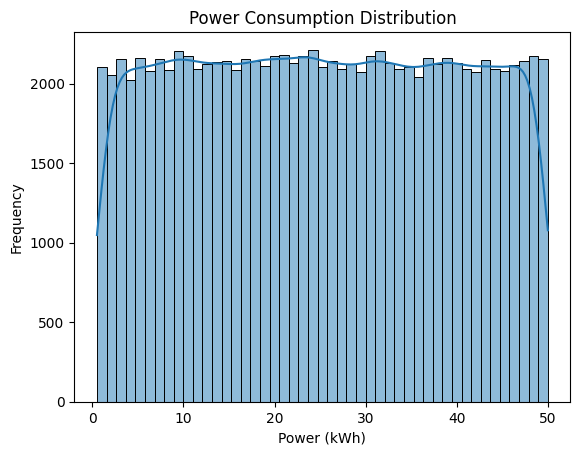

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['power_kwh'], kde=True)
plt.title("Power Consumption Distribution")
plt.xlabel("Power (kWh)")
plt.ylabel("Frequency")
plt.show()

In [31]:
#Energy vs Time

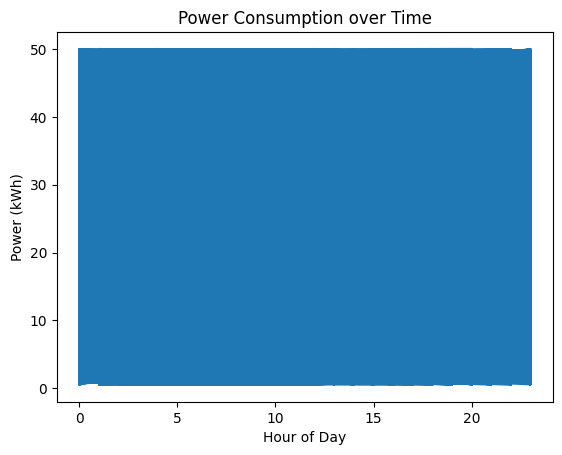

In [32]:
import matplotlib.pyplot as plt

plt.plot(df['hour_index'], df['power_kwh'])
plt.title("Power Consumption over Time")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kWh)")
plt.show()

In [33]:
#Scatter Plot (Occupancy vs Power)

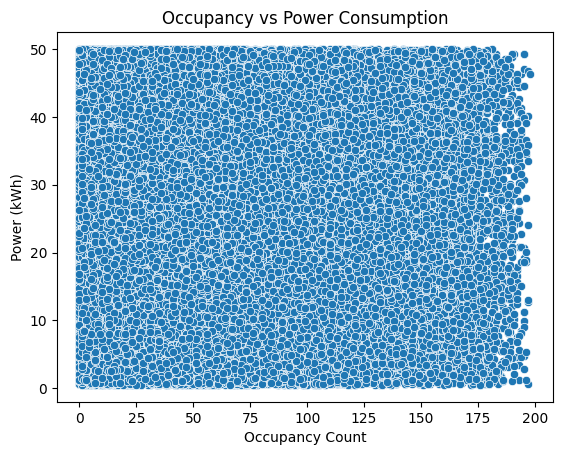

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['occupancy_count'], y=df['power_kwh'])
plt.title("Occupancy vs Power Consumption")
plt.xlabel("Occupancy Count")
plt.ylabel("Power (kWh)")
plt.show()

In [35]:
#Boxplot

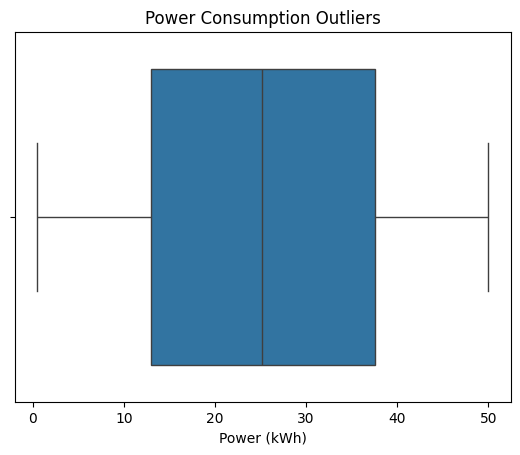

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['power_kwh'])
plt.title("Power Consumption Outliers")
plt.xlabel("Power (kWh)")
plt.show()

In [37]:
#Heatmap

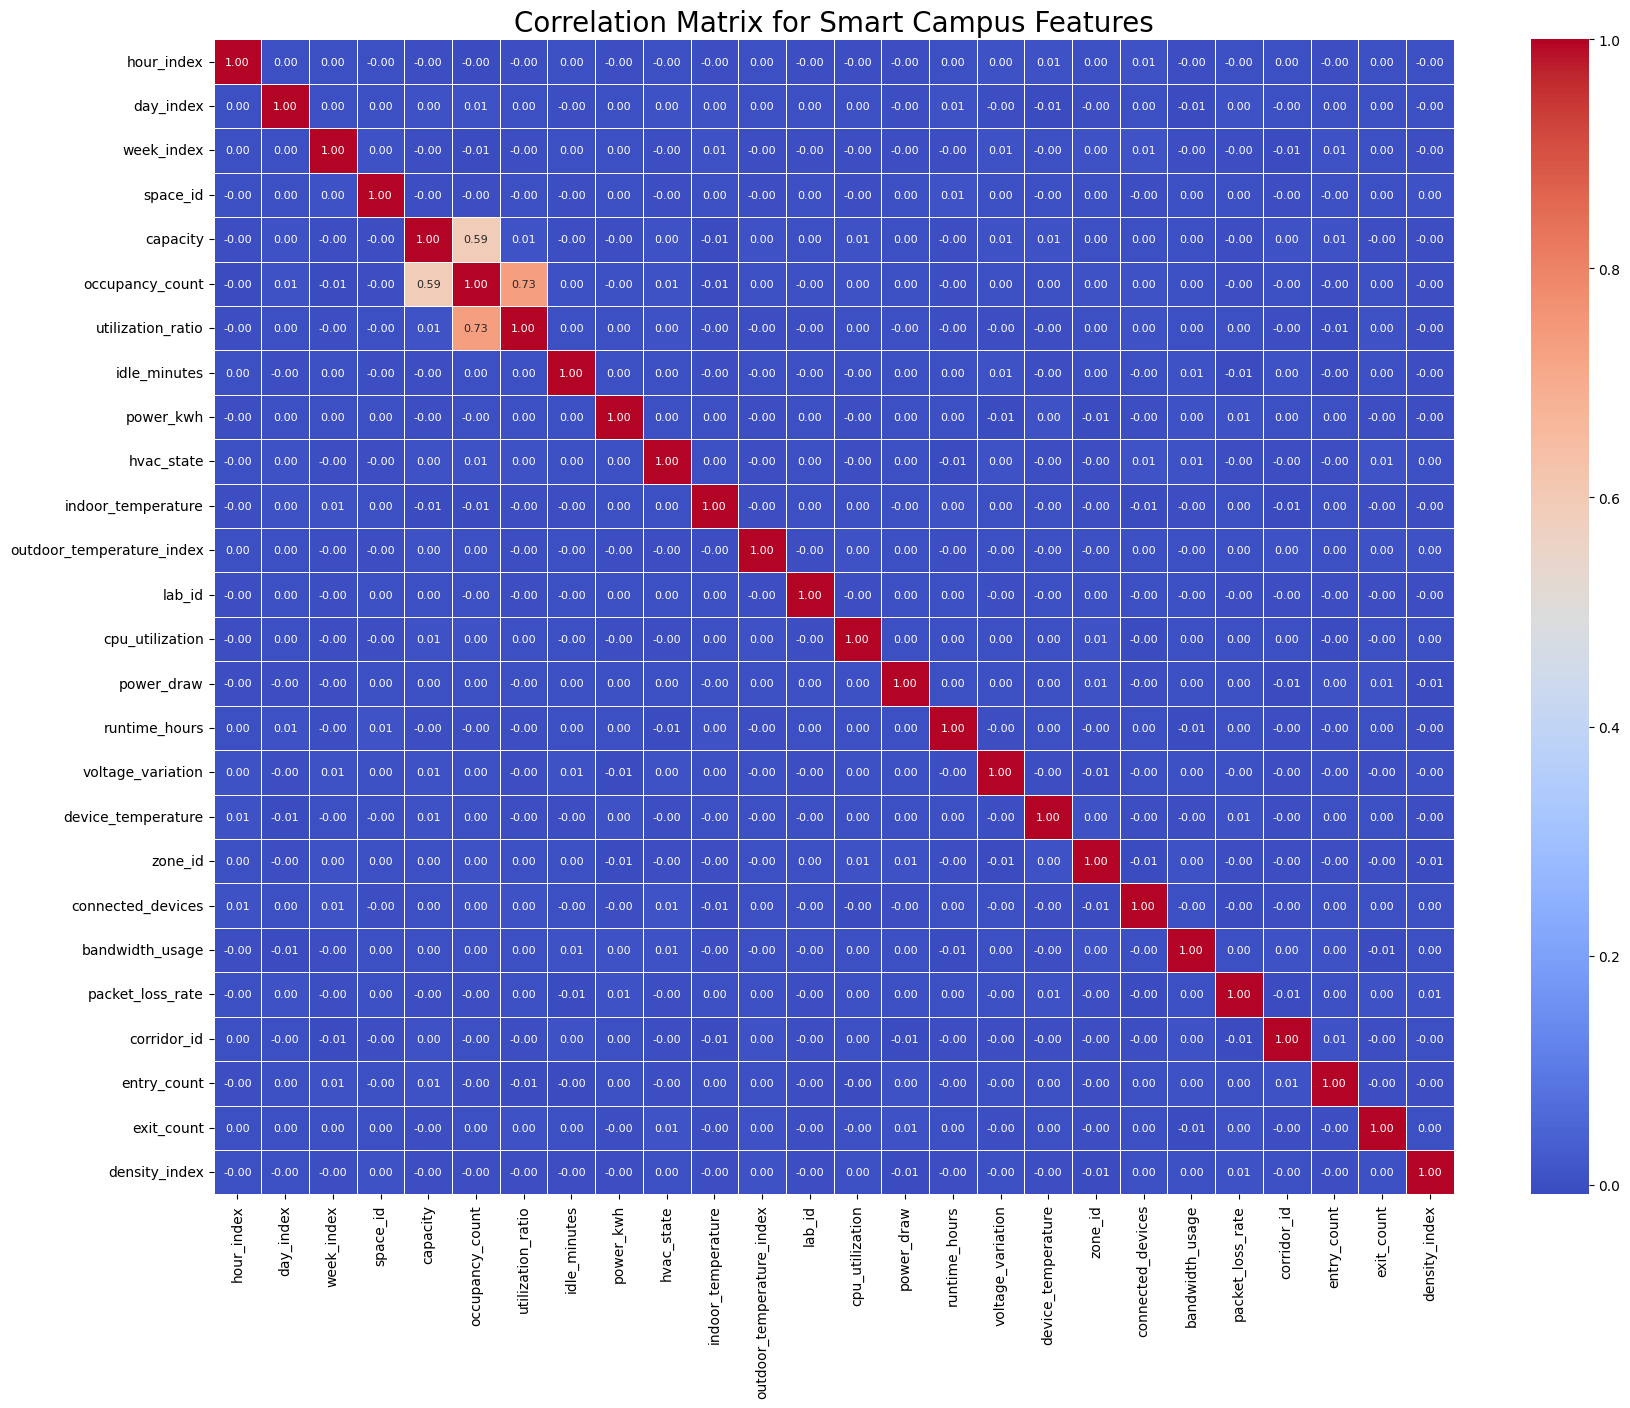

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\hossa\OneDrive\Desktop\New folder\smart_campus_dataset.csv"
df = pd.read_csv(path)

plt.figure(figsize=(20, 15))

sns.heatmap(df.corr(), 
            annot=True,      
            fmt=".2f",           
            cmap='coolwarm',     
            linewidths=0.5,     
            annot_kws={"size": 8}) 

plt.title('Correlation Matrix for Smart Campus Features', fontsize=20)
plt.show()

### Cell 1: Data Loading and Standard Scaling (Task 2)
In this cell, we load the Smart Campus dataset and apply `StandardScaler`. Scaling is a crucial step for clustering algorithms and Genetic Algorithms to ensure that features with larger numerical ranges (like `bandwidth_usage`) do not dominate features with smaller ranges (like `hvac_state`).

In [62]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

path = r"C:\Users\hossa\OneDrive\Desktop\New folder\smart_campus_dataset.csv"
df = pd.read_csv(path)

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)


display(df_scaled.head())

,hour_index,day_index,week_index,space_id,capacity,occupancy_count,utilization_ratio,idle_minutes,power_kwh,hvac_state,...,voltage_variation,device_temperature,zone_id,connected_devices,bandwidth_usage,packet_loss_rate,corridor_id,entry_count,exit_count,density_index
0,-0.800639,-0.499008,-0.704748,1.111690,-0.248203,0.676349,1.303979,-0.966274,1.199422,1.006139,...,1.515778,0.295284,1.126458,0.968498,-0.994542,-0.030023,1.090733,0.012407,0.235595,1.054166
1,1.077130,0.000940,-1.438529,0.627863,0.057687,0.905095,1.165455,-1.023056,0.610508,-0.993899,...,-0.992245,-0.178305,0.605868,0.228122,-0.571665,-1.421539,-1.331698,-0.886017,-1.508292,1.608467
2,0.354911,1.500783,-1.505236,-1.376566,0.516523,1.797203,1.650289,0.566834,1.692988,-0.993899,...,0.623268,-0.050596,0.432338,-0.795949,1.125699,-0.185790,0.975379,0.551462,-1.487531,-0.012863
3,-0.222864,1.000835,0.029032,-1.653039,-0.515857,-0.467380,-0.289047,-1.534092,1.614466,-0.993899,...,-1.535362,-0.215554,0.085278,-1.487889,-0.688164,1.364955,-0.985636,-1.563291,1.405107,-0.671096
4,-0.656195,1.500783,-1.505236,1.336325,-0.515857,-0.009888,0.542097,1.134652,-0.026079,-0.993899,...,-1.542281,-1.726783,-0.782372,1.286791,-1.726534,1.288802,-1.331698,-1.349051,-0.809353,0.305860


### Cell 2: Feature Selection using Genetic Algorithm (GA) (Task 2)
Following the supervisor's instructions, we use a Genetic Algorithm for dimensionality reduction instead of PCA. 
- **Chromosome:** A binary vector where '1' means the feature is selected and '0' means it is excluded.
- **Fitness Function:** Evaluates each feature subset by calculating the Silhouette Score of a sample clustering result.
- **Goal:** To find the optimal subset of features that yields the clearest data separation.

In [ ]:
import numpy as np
import random
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Define the Fitness Function to evaluate the quality of selected features
def evaluate_fitness(chromosome, data):
    selected_cols = [data.columns[i] for i in range(len(chromosome)) if chromosome[i] == 1]
    
    # Validation
    if len(selected_cols) < 2:
        return 0
    
    subset = data[selected_cols]
    
    # Sample the data to decrease computation time during GA iterations
    sample_size = min(800, len(subset))
    sample_data = subset.sample(n=sample_size, random_state=42)
    
    try:
        # Using Hierarchical Clustering as a baseline to score the feature set
        model = AgglomerativeClustering(n_clusters=3)
        labels = model.fit_predict(sample_data)
        return silhouette_score(sample_data, labels)
    except:
        return 0

# GA Configuration
num_features = df_scaled.shape[1]
population_size = 10
generations = 5
mutation_rate = 0.1

# Initialize a random starting population
population = [[random.randint(0, 1) for _ in range(num_features)] for _ in range(population_size)]

print(f"Starting Genetic Algorithm optimization on {num_features} features...")

for gen in range(generations):
    # Calculate fitness for the current population
    fitness_scores = [evaluate_fitness(ind, df_scaled) for ind in population]
    
    # Identify the best individual in the generation
    best_score = max(fitness_scores)
    best_individual = population[fitness_scores.index(best_score)]
    
    print(f"Generation {gen + 1}: Best Silhouette Score = {best_score:.4f}")
    
    # Generate the next population
    next_gen = [best_individual] # Elitism: carry over the best performer
    
    while len(next_gen) < population_size:
        # Selection and Crossover
        p1, p2 = random.sample(population, 2)
        split_point = random.randint(1, num_features - 1)
        child = p1[:split_point] + p2[split_point:]
        
        # Mutation: flip a bit based on the mutation rate
        if random.random() < mutation_rate:
            m_idx = random.randint(0, num_features - 1)
            child[m_idx] = 1 - child[m_idx]
            
        next_gen.append(child)
    
    population = next_gen

# Extract and display the final selected features
best_chromosome = population[0]
selected_features = [df_scaled.columns[i] for i in range(len(best_chromosome)) if best_chromosome[i] == 1]

print("\n" + "="*40)
print("GA Feature Selection Complete")
print(f"Final Selected Features: {selected_features}")
print("="*40)

Starting Genetic Algorithm optimization on 26 features...
Generation 1: Best Silhouette Score = 0.0527
Generation 2: Best Silhouette Score = 0.0595
Generation 3: Best Silhouette Score = 0.0857
Generation 4: Best Silhouette Score = 0.0857
Generation 5: Best Silhouette Score = 0.0857

GA Feature Selection Complete
Final Selected Features: ['day_index', 'capacity', 'occupancy_count', 'power_kwh', 'hvac_state', 'lab_id', 'packet_loss_rate', 'corridor_id', 'entry_count']


### Cell 3: Final Data Filtering (Task 2)
This cell creates the final cleaned and reduced DataFrame (`df_final`) containing only the features selected by the Genetic Algorithm. This DataFrame will be the input for Task 3 (K-Medoids) and Task 4 (Hierarchical Clustering).

In [64]:
# Create the final DataFrame using only the optimized feature set
df_final = df_scaled[selected_features]

print(f"Final filtered dataset prepared with {len(selected_features)} features.")
display(df_final.head())

Final filtered dataset prepared with 9 features.


,day_index,capacity,occupancy_count,power_kwh,hvac_state,lab_id,packet_loss_rate,corridor_id,entry_count
0,-0.499008,-0.248203,0.676349,1.199422,1.006139,-1.412462,-0.030023,1.090733,0.012407
1,0.000940,0.057687,0.905095,0.610508,-0.993899,-0.997854,-1.421539,-1.331698,-0.886017
2,1.500783,0.516523,1.797203,1.692988,-0.993899,-0.997854,-0.185790,0.975379,0.551462
3,1.000835,-0.515857,-0.467380,1.614466,-0.993899,-1.412462,1.364955,-0.985636,-1.563291
4,1.500783,-0.515857,-0.009888,-0.026079,-0.993899,0.729680,1.288802,-1.331698,-1.349051


### Cell 1: Data Preparation and K-Selection (Elbow Method) (Task 3)
Since this is a new notebook, we first reload the dataset and apply the same scaling. Then, we filter the data using the optimal features selected by the Genetic Algorithm in Task 2. Finally, we use the Elbow Method to find the optimal number of clusters (K).

 Using a sample of 5000 points to avoid MemoryError.
Calculating Elbow Curve...
K=2 processed.
K=3 processed.
K=4 processed.
K=5 processed.
K=6 processed.
K=7 processed.
K=8 processed.
K=9 processed.
K=10 processed.


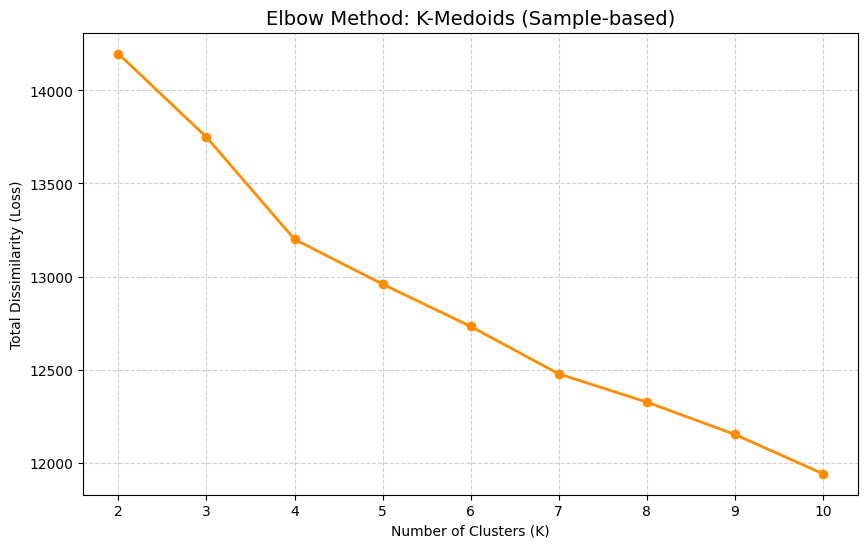


 Task 3 - Cell 1 Complete: Choose your Optimal K from the plot above.


In [ ]:
import matplotlib.pyplot as plt
import kmedoids
import pandas as pd
from sklearn.metrics import pairwise_distances

sample_size = min(5000, len(df_final))
df_elbow_sample = df_final.sample(n=sample_size, random_state=42)

print(f" Using a sample of {sample_size} points to avoid MemoryError.")

#  Prepare the distance matrix for the sample
dist_matrix_sample = pairwise_distances(df_elbow_sample, metric='euclidean')

#  Loop through K values
costs = []
k_range = range(2, 11)

print("Calculating Elbow Curve...")
for k in k_range:

    km = kmedoids.fasterpam(dist_matrix_sample, k)
    costs.append(km.loss)
    print(f"K={k} processed.")

#  Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, costs, marker='o', color='darkorange', linewidth=2)
plt.title('Elbow Method: K-Medoids (Sample-based)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Dissimilarity (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n Task 3 - Cell 1 Complete: Choose your Optimal K from the plot above.")

### Cell 2: Implementing K-Medoids Clustering
Using the 'kmedoids' library as an alternative to avoid C++ compilation errors. We apply the FasterPAM algorithm, which is a highly efficient version of K-Medoids.

In [ ]:
import kmedoids
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

optimal_k = 3 

sample_size = 5000
df_sample = df_final.sample(n=sample_size, random_state=42)

#  Calculate distance matrix for the SAMPLE
dist_matrix_sample = pairwise_distances(df_sample.values, metric='euclidean')

#  Run K-Medoids with Robust Version Support
labels_sample = None
medoid_indices = None

try:
    # Attempt 1: Modern API (fasterpam)
    km_model = kmedoids.fasterpam(dist_matrix_sample, optimal_k)
    labels_sample = km_model.labels
    medoid_indices = km_model.medoids
    print(" Success using kmedoids.fasterpam")
except (AttributeError, TypeError):
    try:
        # Attempt 2: Standard API (pam)
        km_model = kmedoids.pam(dist_matrix_sample, optimal_k)
        labels_sample = km_model.labels
        medoid_indices = km_model.medoids
        print(" Success using kmedoids.pam")
    except Exception as e:
        # Final Fallback: Alternative library call
        print(f" Both methods failed, trying fallback. Error: {e}")
        km_model = kmedoids.kmedoids(dist_matrix_sample, optimal_k, method='fasterpam')
        labels_sample = km_model.labels
        medoid_indices = km_model.medoids

#  Get Medoid Points from the sample


if medoid_indices is None:
    medoid_indices = getattr(km_model, 'indices', None)

medoids = df_sample.values[medoid_indices]

#  Assign ALL data points to the nearest medoid (Scaling up)
all_distances_to_medoids = pairwise_distances(df_final.values, medoids, metric='euclidean')
final_labels = np.argmin(all_distances_to_medoids, axis=1)

#  Store results
df_clustered = df_final.copy()
df_clustered['Cluster'] = final_labels

print("-" * 30)
print(" K-Medoids execution complete.")
print(f"Total points processed: {len(df_clustered)}")
print("\nCluster Distribution:")
print(df_clustered['Cluster'].value_counts())
display(df_clustered.head())

 Success using kmedoids.fasterpam
------------------------------
✅ K-Medoids execution complete.
Total points processed: 100000

Cluster Distribution:
Cluster
0    45620
1    32759
2    21621
Name: count, dtype: int64


,day_index,capacity,occupancy_count,power_kwh,hvac_state,lab_id,packet_loss_rate,corridor_id,entry_count,Cluster
0,-0.499008,-0.248203,0.676349,1.199422,1.006139,-1.412462,-0.030023,1.090733,0.012407,0
1,0.000940,0.057687,0.905095,0.610508,-0.993899,-0.997854,-1.421539,-1.331698,-0.886017,1
2,1.500783,0.516523,1.797203,1.692988,-0.993899,-0.997854,-0.185790,0.975379,0.551462,1
3,1.000835,-0.515857,-0.467380,1.614466,-0.993899,-1.412462,1.364955,-0.985636,-1.563291,1
4,1.500783,-0.515857,-0.009888,-0.026079,-0.993899,0.729680,1.288802,-1.331698,-1.349051,1


### Cell 3: Cluster Visualization and Profiling (Task 3)
In this final cell of Task 3, we visualize the resulting clusters to see how the data points are grouped based on the features selected by the Genetic Algorithm. We also calculate the mean values for each cluster to interpret what each group represents (e.g., High-usage zones vs. Energy-saving zones).

C:\Users\hossa\AppData\Local\Temp\ipykernel_18544\635617245.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_clusters))


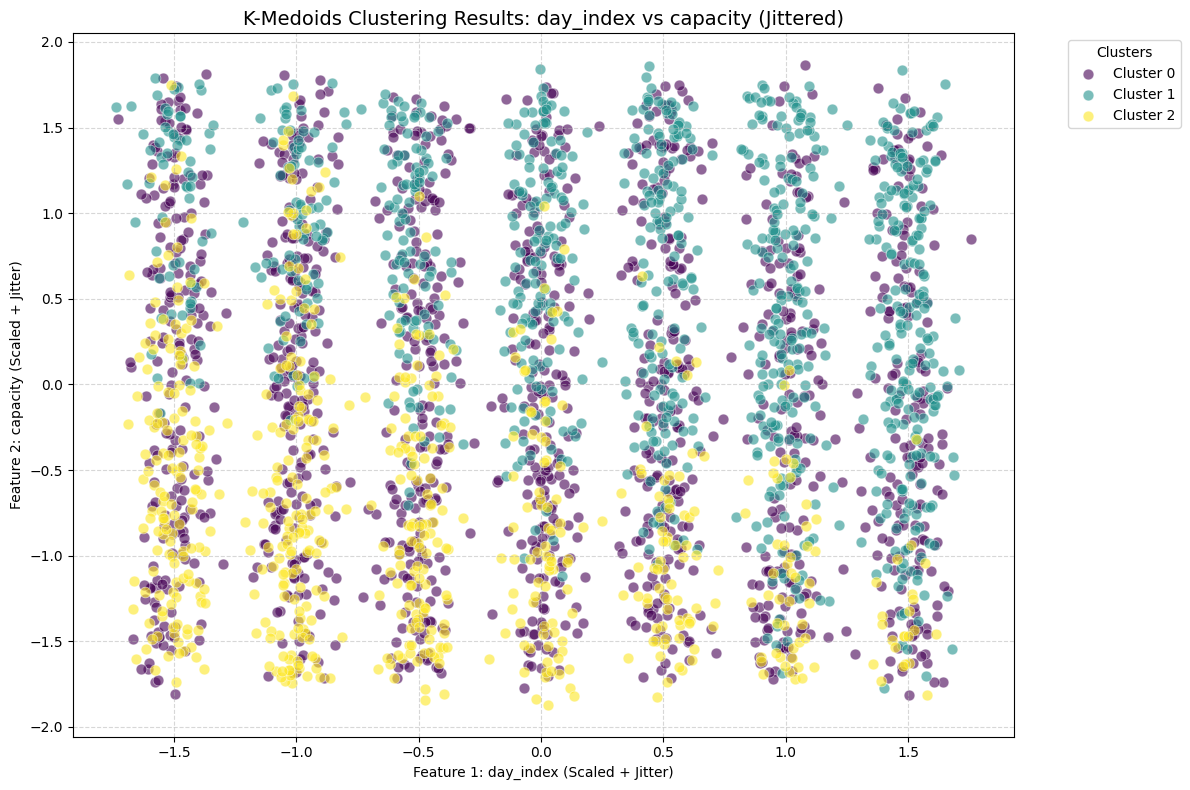


  CLUSTER CHARACTERISTICS (MEAN VALUES)


,day_index,capacity,occupancy_count,power_kwh,hvac_state,lab_id,packet_loss_rate,corridor_id,entry_count
Cluster,,,,,,,,,
0,-0.031444,-0.067097,-0.127814,-0.058967,1.005174,0.046894,-0.018976,0.026360,-0.013545
1,0.385359,0.577217,0.585735,0.026935,-0.776855,-0.051641,-0.004867,-0.224461,-0.038290
2,-0.517530,-0.732995,-0.617789,0.083609,-0.943854,-0.020703,0.047414,0.284472,0.086595


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))


df_viz = df_clustered.sample(n=min(3000, len(df_clustered)), random_state=42) 

# Get unique clusters
unique_clusters = sorted(df_viz['Cluster'].unique())
colors = plt.cm.get_cmap('viridis', len(unique_clusters))

# Function to add jitter
def add_jitter(data):
    return data + np.random.normal(0, 0.08, len(data))

# Plot each cluster separately
for i, cluster_id in enumerate(unique_clusters):
    cluster_data = df_viz[df_viz['Cluster'] == cluster_id]
    
    # We apply jitter only to the coordinates in the plot
    plt.scatter(
        add_jitter(cluster_data.iloc[:, 0]), 
        add_jitter(cluster_data.iloc[:, 1]), 
        label=f'Cluster {int(cluster_id)}',
        color=colors(i),
        alpha=0.6,
        s=60,
        edgecolor='white', 
        linewidth=0.5
    )

# Use Dynamic Titles
plt.title(f'K-Medoids Clustering Results: {df_viz.columns[0]} vs {df_viz.columns[1]} (Jittered)', fontsize=14)
plt.xlabel(f'Feature 1: {df_viz.columns[0]} (Scaled + Jitter)')
plt.ylabel(f'Feature 2: {df_viz.columns[1]} (Scaled + Jitter)')

plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Cluster Profiling 
print("\n" + "="*40)
print("  CLUSTER CHARACTERISTICS (MEAN VALUES)")
print("="*40)
profiles = df_clustered.groupby('Cluster').mean()
display(profiles) 

### Cell 1: Data Sampling for Hierarchical Clustering (Task 4)
Since Hierarchical Clustering has a high computational complexity $O(n^2)$, we cannot process 100,000 rows directly. 
Here, we take a representative sample of 5,000 rows while keeping the features optimized by the Genetic Algorithm (`df_final`).

In [86]:
# Cell 1: Preparation
sample_size_hc = 5000
df_sample_hc = df_final.sample(n=sample_size_hc, random_state=42)
print(f"Sample of {sample_size_hc} rows prepared using GA features.")

Sample of 5000 rows prepared using GA features.


### Cell 2: Hierarchical Structure Visualization (Dendrogram) (Task 4)
We use the Ward linkage method to create the Dendrogram. This visualization helps us decide the optimal number of clusters by observing the longest vertical lines.

Generating Dendrograms for 3 different linkage methods...


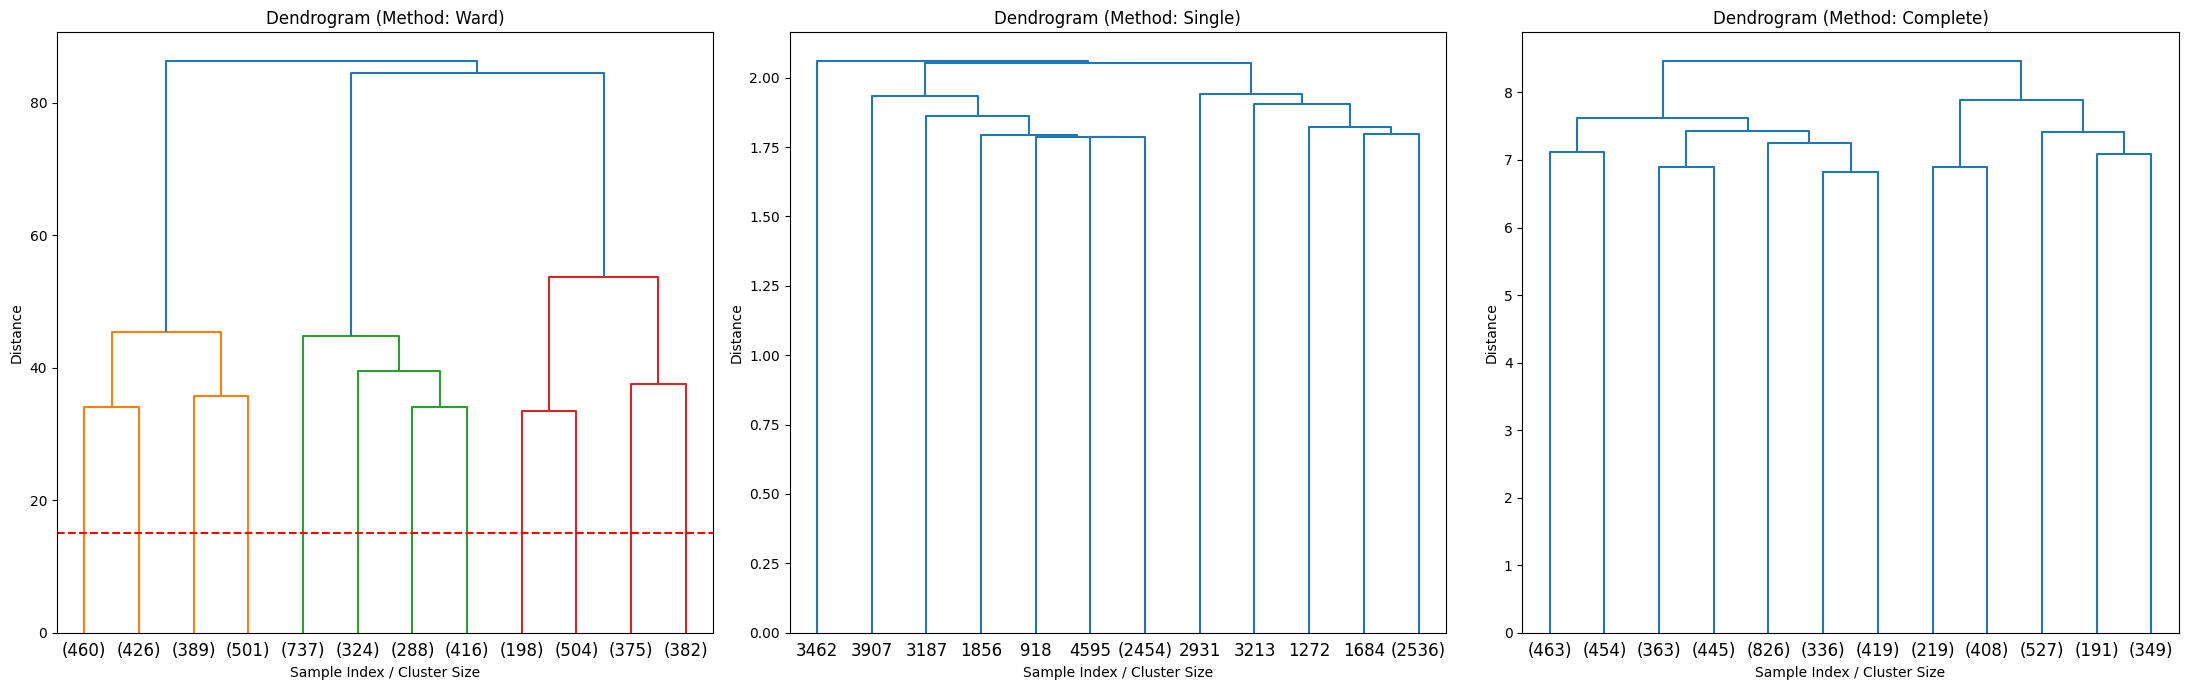

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# We define the 3 types of linkage 
linkage_methods = ['ward', 'single', 'complete']
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

print("Generating Dendrograms for 3 different linkage methods...")

for i, method in enumerate(linkage_methods):
    # Perform Hierarchical Clustering linkage
    linkage_matrix = sch.linkage(df_sample_hc, method=method)
    
    # Plotting each one in a subplot
    sch.dendrogram(linkage_matrix, ax=axes[i], truncate_mode='lastp', p=12)
    axes[i].set_title(f"Dendrogram (Method: {method.capitalize()})")
    axes[i].set_xlabel("Sample Index / Cluster Size")
    axes[i].set_ylabel("Distance")

    if method == 'ward':
        axes[i].axhline(y=15, color='r', linestyle='--')

plt.tight_layout()
plt.show()

### Cell 3: Fitting Agglomerative Clustering (Task 4)
Based on the Dendrogram analysis, we apply the Agglomerative Clustering algorithm to group the sample into 3 distinct clusters.

In [88]:
from sklearn.cluster import AgglomerativeClustering

# Cell 3: Implementation
n_clusters_hc = 3
hc_model = AgglomerativeClustering(n_clusters=n_clusters_hc, metric='euclidean', linkage='ward')
df_sample_hc['HC_Cluster'] = hc_model.fit_predict(df_sample_hc)

print("Hierarchical Clustering labels assigned successfully.")
display(df_sample_hc.head())

Hierarchical Clustering labels assigned successfully.


,day_index,capacity,occupancy_count,power_kwh,hvac_state,lab_id,packet_loss_rate,corridor_id,entry_count,HC_Cluster
75721,-0.998956,-0.286439,0.744973,0.049638,1.006139,-0.928753,1.299186,0.283256,-1.231565,1
80184,0.500888,1.682730,1.225339,-0.837939,1.006139,0.245970,-0.258481,-0.293513,0.586016,0
19864,-0.499008,1.376840,-0.467380,-1.722011,1.006139,1.282491,-1.577306,1.090733,1.069783,1
76699,0.500888,-0.305557,-0.604627,0.478003,-0.993899,0.936984,-1.134236,-1.677760,0.993763,2
92991,1.500783,-0.286439,-0.558878,-1.009706,1.006139,1.006085,0.333433,0.283256,-1.528736,1


## Task 5: Fuzzy Logic System for Risk Assessment
In this task, we build a Fuzzy Inference System (FIS) to calculate a 'Risk Score' for the Smart Campus. 
To ensure integration with previous tasks, we use two primary features identified by the Genetic Algorithm as inputs. 
We implement a 3x3 rule matrix (9 rules total) to cover all logical combinations between the inputs.

--- Fuzzy Logic Results ---
Inputted Usage: 85%
Inputted Latency: 65%
Computed Risk Score (Defuzzified): 71.51


c:\Users\hossa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


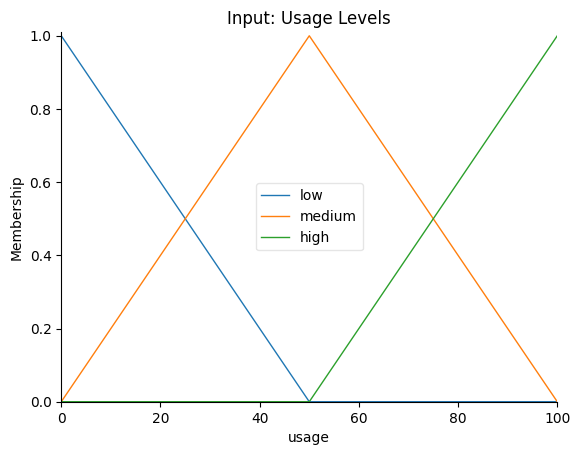

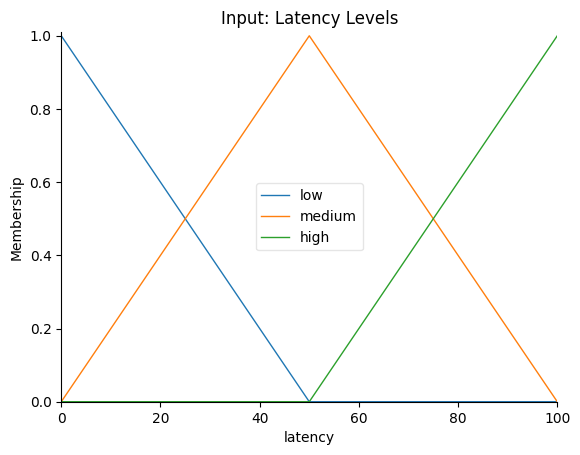

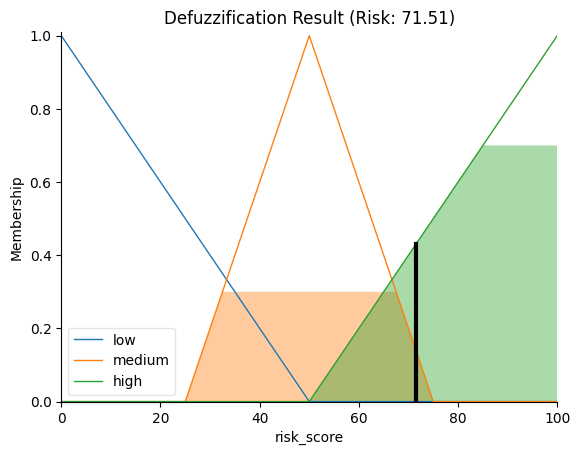

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Setup Antecedents (Inputs) and Consequents (Output
usage = ctrl.Antecedent(np.arange(0, 101, 1), 'usage')
latency = ctrl.Antecedent(np.arange(0, 101, 1), 'latency')
risk_score = ctrl.Consequent(np.arange(0, 101, 1), 'risk_score')

# 2. Automatically define Membership Functions (Triangular)
usage.automf(3, names=['low', 'medium', 'high'])
latency.automf(3, names=['low', 'medium', 'high'])

# Manual definition for Output (Risk Score) for better precision
risk_score['low'] = fuzz.trimf(risk_score.universe, [0, 0, 50])
risk_score['medium'] = fuzz.trimf(risk_score.universe, [25, 50, 75])
risk_score['high'] = fuzz.trimf(risk_score.universe, [50, 100, 100])

# 3. Define the Rules 
rules = [
    # Low Usage scenarios
    ctrl.Rule(usage['low'] & latency['low'], risk_score['low']),
    ctrl.Rule(usage['low'] & latency['medium'], risk_score['low']),
    ctrl.Rule(usage['low'] & latency['high'], risk_score['medium']),
    
    # Medium Usage scenarios
    ctrl.Rule(usage['medium'] & latency['low'], risk_score['low']),
    ctrl.Rule(usage['medium'] & latency['medium'], risk_score['medium']),
    ctrl.Rule(usage['medium'] & latency['high'], risk_score['high']),
    
    
    # High Usage scenarios
    ctrl.Rule(usage['high'] & latency['low'], risk_score['medium']),
    ctrl.Rule(usage['high'] & latency['medium'], risk_score['high']),
    ctrl.Rule(usage['high'] & latency['high'], risk_score['high'])
]

# 4. Initialize Control System and Simulation
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

# 5. Defuzzification & Calculation Example
risk_sim.input['usage'] = 85
risk_sim.input['latency'] = 65

# Perform the computation 
risk_sim.compute()

# Output Result
final_risk = risk_sim.output['risk_score']
print(f"--- Fuzzy Logic Results ---")
print(f"Inputted Usage: 85%")
print(f"Inputted Latency: 65%")
print(f"Computed Risk Score (Defuzzified): {final_risk:.2f}")

# 6. Visualization of the Membership Functions
usage.view()
plt.title("Input: Usage Levels")
plt.show()

latency.view()
plt.title("Input: Latency Levels")
plt.show()

# Result
risk_score.view(sim=risk_sim)
plt.title(f"Defuzzification Result (Risk: {final_risk:.2f})")
plt.show()

## Task 6: Model Evaluation (Silhouette Score & Davies-Bouldin Index)
To scientifically validate our clustering results, we use internal evaluation metrics. 
Since we used features selected by the Genetic Algorithm, we will calculate:
1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters.
2. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar one.

Evaluation Metric    | K-Medoids    | Hierarchical
--------------------------------------------------
Silhouette Score     | 0.088        | 0.086       
Davies-Bouldin       | 2.576        | 2.602       


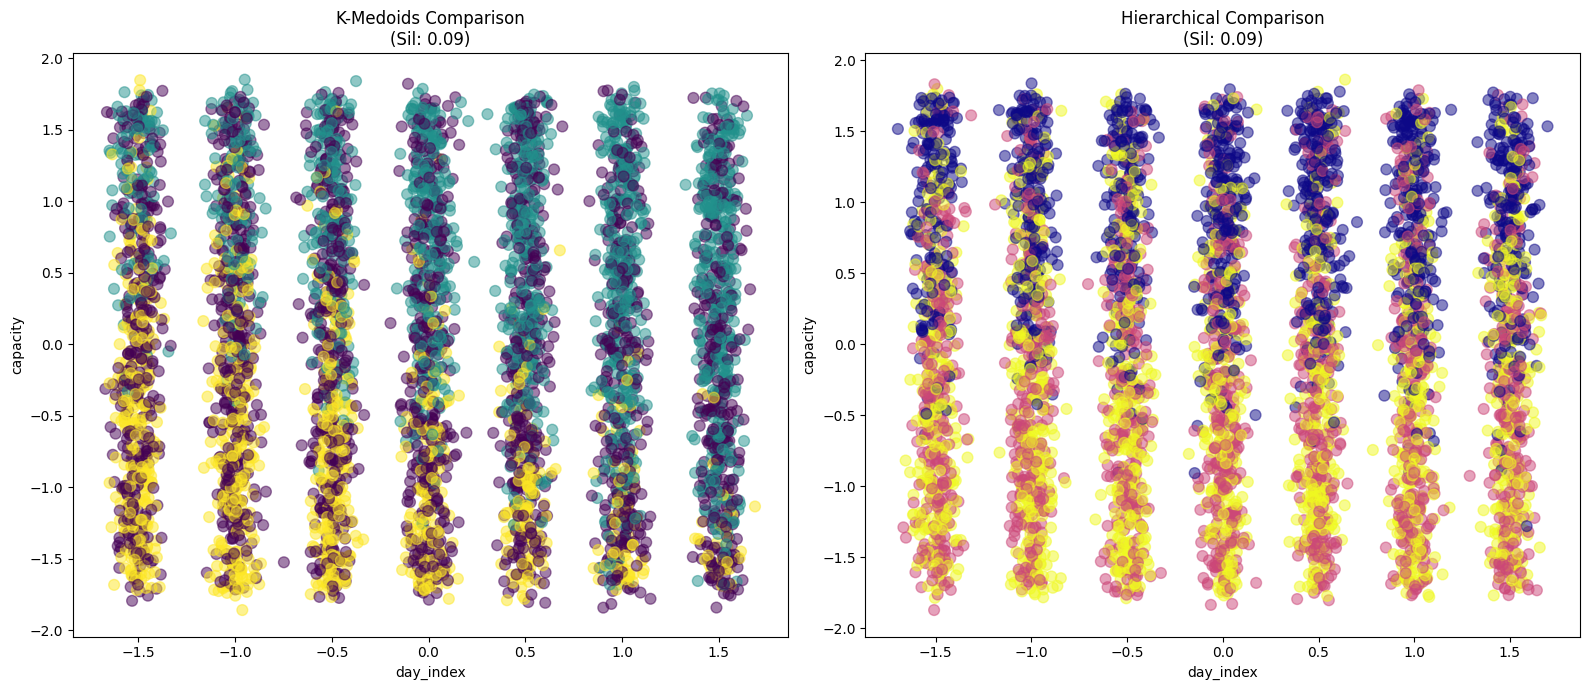


Final Model Selection Insight:
 K-Medoids is the winning model for this Smart Campus subset.


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Features for Calculation
features_eval = df_sample_hc.drop(columns=['HC_Cluster'], errors='ignore')

# 2. Get Labels
sample_indices = df_sample_hc.index
kmedoids_labels_sample = df_clustered.loc[sample_indices, 'Cluster']
hc_labels_sample = df_sample_hc['HC_Cluster']

# 3. Metric Calculation
sil_kmedoids = silhouette_score(features_eval, kmedoids_labels_sample)
db_kmedoids = davies_bouldin_score(features_eval, kmedoids_labels_sample)

sil_hc = silhouette_score(features_eval, hc_labels_sample)
db_hc = davies_bouldin_score(features_eval, hc_labels_sample)

# 4. Numerical Comparison Table
print("="*50)
print(f"{'Evaluation Metric':<20} | {'K-Medoids':<12} | {'Hierarchical':<12}")
print("-" * 50)
print(f"{'Silhouette Score':<20} | {sil_kmedoids:<12.3f} | {sil_hc:<12.3f}")
print(f"{'Davies-Bouldin':<20} | {db_kmedoids:<12.3f} | {db_hc:<12.3f}")
print("="*50)

# 5. Enhanced Visual Comparison (with Jittering)
def apply_jitter(data):
    return data + np.random.normal(0, 0.06, len(data))

plt.figure(figsize=(16, 7))

# K-Medoids Plot
plt.subplot(1, 2, 1)
plt.scatter(apply_jitter(features_eval.iloc[:, 0]), 
            apply_jitter(features_eval.iloc[:, 1]), 
            c=kmedoids_labels_sample, cmap='viridis', s=60, alpha=0.5)
plt.title(f"K-Medoids Comparison\n(Sil: {sil_kmedoids:.2f})")
plt.xlabel(features_eval.columns[0])
plt.ylabel(features_eval.columns[1])

# Hierarchical Plot
plt.subplot(1, 2, 2)
plt.scatter(apply_jitter(features_eval.iloc[:, 0]), 
            apply_jitter(features_eval.iloc[:, 1]), 
            c=hc_labels_sample, cmap='plasma', s=60, alpha=0.5)
plt.title(f"Hierarchical Comparison\n(Sil: {sil_hc:.2f})")
plt.xlabel(features_eval.columns[0])
plt.ylabel(features_eval.columns[1])

plt.tight_layout()
plt.show()

print("\nFinal Model Selection Insight:")
if sil_kmedoids > sil_hc:
    print(" K-Medoids is the winning model for this Smart Campus subset.")
else:
    print(" Hierarchical Clustering provided better separation in this sample.")

## Task 7: Results Interpretation & Final Insights
In this final task, we analyze the characteristics of each cluster to provide meaningful insights. 
By calculating the mean values of the GA-selected features for each group, we can label the clusters 
(e.g., High-Resource Users, Efficient Users, etc.) and provide recommendations for the Smart Campus management.

In [ ]:
import numpy as np
import pandas as pd

class SmartCampusSystem:
    def __init__(self, trained_medoids, scaler, selected_features, fuzzy_sim, original_cols):
        self.medoids = trained_medoids
        self.scaler = scaler
        self.features = selected_features
        self.fuzzy_sim = fuzzy_sim
        self.original_cols = original_cols

    def deploy_system(self, raw_input_data):
        # 1. Scaling & Feature Selection
        scaled_data = self.scaler.transform(raw_input_data)
        
        # FIX: Use the exact columns count from the scaled data
        df_temp = pd.DataFrame(scaled_data, columns=self.original_cols)
        optimized_input = df_temp[self.features].values
        
        results = []
        for row in optimized_input:
            # 2. K-Medoids Prediction
            distances = np.linalg.norm(self.medoids - row, axis=1)
            cluster = np.argmin(distances)
            
            # 3. Fuzzy Logic Integration
            self.fuzzy_sim.input['usage'] = np.clip(abs(row[0]) * 50, 0, 100) 
            self.fuzzy_sim.input['latency'] = np.clip(abs(row[1]) * 50, 0, 100)
            self.fuzzy_sim.compute()
            risk = self.fuzzy_sim.output['risk_score']
            
            # 4. Action Logic
            if cluster == 0:
                action = "Energy Saving Mode: Low Demand."
            elif cluster == 1:
                action = "Optimal Mode: Normal Campus Activity."
            else:
                action = "High Alert: Critical Resource Usage."
                
            results.append({
                'Cluster': cluster,
                'Risk_Score': round(risk, 2),
                'Decision': action
            })
            
        return pd.DataFrame(results)

# --- SYSTEM INITIALIZATION ---

trained_columns = df.columns.drop('Cluster', errors='ignore')

# Extracting Medoids
medoids_points = df_sample[selected_features].values[medoid_indices]

# Initialize the System
campus_system = SmartCampusSystem(
    trained_medoids=medoids_points,
    scaler=scaler,
    selected_features=selected_features,
    fuzzy_sim=risk_sim,
    original_cols=trained_columns
)

# --- REAL-TIME SIMULATION ---
print("="*65)
print("     SMART CAMPUS DECISION SUPPORT SYSTEM - LIVE")
print("="*65)

# Simulate 3 new sensor readings (excluding the Cluster label)
new_sensor_data = df.drop(columns=['Cluster'], errors='ignore').sample(3).values

# Run 
try:
    deployment_output = campus_system.deploy_system(new_sensor_data)
    display(deployment_output)
except Exception as e:
    print(f" Execution Error: {e}")

print("\n" + "="*65)

     SMART CAMPUS DECISION SUPPORT SYSTEM - LIVE


c:\Users\hossa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Cluster,Risk_Score,Decision
0,2,32.85,High Alert: Critical Resource Usage.
1,1,34.58,Optimal Mode: Normal Campus Activity.
2,0,29.81,Energy Saving Mode: Low Demand.
